# Cox-Time

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn_pandas import DataFrameMapper
import torch
import torchtuples as tt

from pycox.models.cox_time import MLPVanillaCoxTime
from pycox.models import CoxTime
from pycox.evaluation import EvalSurv

In [2]:
SEED = 50

In [3]:
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

## Dataset

In [ ]:
from dataset_11t5g_markov import DatasetMarkovSurvSurf

ds_name = 'markov_32feat_11t5g_more_balanced_largeN_censor'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
project = 'SurvSurfBenchmark_Markov_censored'
SAVE_PATH = f'./pycox_models/more_g/{project}/cox_time_pycox_more_g_{SEED}'
g_resol = 1
t_resol = 1
split = 'train'
ds = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_train = ds._get_df_Xy_trans_obs_more_g()

split = 'test'
ds = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_test = ds._get_df_Xy_true_prob()

split = 'val'
ds = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_val = ds._get_df_Xy_trans_obs_more_g()

In [5]:
df_test

,subject,g_max_by_time,duration,event_observed,feat00,feat01,feat02,feat03,feat04,feat05,...,feat24,feat25,feat26,feat27,feat28,feat29,feat30,feat31,weight,is_t_trans
0,1,1,0,0.000000,0.932866,2.059838,-0.934938,-1.612990,0.527070,-1.551101,...,-0.219661,1.503398,-1.482385,-0.856164,-0.828693,0.114048,0.527728,1.0,1,NaN
1,1,2,0,0.000000,0.932866,2.059838,-0.934938,-1.612990,0.527070,-1.551101,...,-0.219661,1.503398,-1.482385,-0.856164,-0.828693,0.114048,0.527728,1.0,1,NaN
2,1,3,0,0.000000,0.932866,2.059838,-0.934938,-1.612990,0.527070,-1.551101,...,-0.219661,1.503398,-1.482385,-0.856164,-0.828693,0.114048,0.527728,1.0,1,NaN
3,1,4,0,0.000000,0.932866,2.059838,-0.934938,-1.612990,0.527070,-1.551101,...,-0.219661,1.503398,-1.482385,-0.856164,-0.828693,0.114048,0.527728,1.0,1,NaN
4,1,5,0,0.000000,0.932866,2.059838,-0.934938,-1.612990,0.527070,-1.551101,...,-0.219661,1.503398,-1.482385,-0.856164,-0.828693,0.114048,0.527728,1.0,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,3999,1,11,0.999999,-1.882847,-0.591056,0.588792,-1.098525,0.211081,-0.399733,...,0.353908,1.593427,-0.369155,-0.173656,-0.658836,0.828539,-1.077051,0.0,1,NaN
149996,3999,2,11,0.904258,-1.882847,-0.591056,0.588792,-1.098525,0.211081,-0.399733,...,0.353908,1.593427,-0.369155,-0.173656,-0.658836,0.828539,-1.077051,0.0,1,NaN
149997,3999,3,11,0.394033,-1.882847,-0.591056,0.588792,-1.098525,0.211081,-0.399733,...,0.353908,1.593427,-0.369155,-0.173656,-0.658836,0.828539,-1.077051,0.0,1,NaN
149998,3999,4,11,0.289010,-1.882847,-0.591056,0.588792,-1.098525,0.211081,-0.399733,...,0.353908,1.593427,-0.369155,-0.173656,-0.658836,0.828539,-1.077051,0.0,1,NaN


In [6]:
df_train.head()

,subject,event_observed,duration,g_max_by_time,feat00,feat01,feat02,feat03,feat04,feat05,...,feat24,feat25,feat26,feat27,feat28,feat29,feat30,feat31,weight,is_t_trans
0,0,0,8,1.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
1,0,0,8,2.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
2,0,0,8,3.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
3,0,0,8,4.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
4,4,1,4,3.0,-0.105813,2.009902,0.011231,-1.089429,-1.514511,-0.559761,...,-1.941266,0.341435,1.862855,-0.295230,0.478317,-0.715190,1.237293,1.0,1,1


## Feature transforms

In [7]:
x_train = df_train.loc[:,df_train.columns.str.startswith('feat')|df_train.columns.str.startswith('g_max_by_time')].astype('float32')
x_train['g_max_by_time'] = x_train['g_max_by_time']/ds.g_max
x_train = x_train.values

x_val = df_val.loc[:,df_val.columns.str.startswith('feat')|df_val.columns.str.startswith('g_max_by_time')].astype('float32')
x_val['g_max_by_time'] = x_val['g_max_by_time']/ds.g_max
x_val = x_val.values

x_test = df_test.loc[:,df_test.columns.str.startswith('feat')|df_test.columns.str.startswith('g_max_by_time')].drop_duplicates().astype('float32')
x_test['g_max_by_time'] = x_test['g_max_by_time']/ds.g_max
x_test = x_test.values



In [8]:
df_train.loc[:,df_train.columns.str.startswith('feat')|df_train.columns.str.startswith('g_max_by_time')].columns == (
    df_test.loc[:,df_test.columns.str.startswith('feat')|df_test.columns.str.startswith('g_max_by_time')].columns
)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

We need no label transforms

In [9]:
get_target = lambda df: (df['duration'].astype('float32').values, df['event_observed'].astype('float32').values)
y_train = get_target(df_train)
y_val = get_target(df_val)
durations_test, events_test = get_target(df_test)
val = tt.tuplefy(x_val, y_val)

In [10]:
val.shapes()

((1884, 33), ((1884,), (1884,)))

With `TupleTree` (the results of `tt.tuplefy`) we can easily repeat the validation dataset multiple times. This will be useful for reduce the variance of the validation loss, as the validation loss of `CoxTime` is not deterministic.

In [11]:
val.repeat(2).cat().shapes()

((3768, 33), ((3768,), (3768,)))

## Neural net
 
We create a simple MLP with two hidden layers, ReLU activations, batch norm and dropout. 
The net required by `CoxTime` is slightly different than most of the other methods as it also take `time` and an additional input argument. 
We have therefore crated the `MLPVanillaCoxTime` class that is a suitable version of `tt.practical.MLPVanilla`.
This class also removes the options for setting `out_features` and `output_bias` as they should be `1` and `False`, respectively.
 
To see the code for the networks call `??MLPVanillaCoxTime`.

In [12]:
in_features = x_train.shape[1]
num_nodes = [32, 32, 32, 32]
batch_norm = False
dropout = 0

net = MLPVanillaCoxTime(in_features, num_nodes, batch_norm, dropout)

## Training the model

In [13]:
model = CoxTime(net, tt.optim.Adam(lr=1e-2, weight_decay=1e-2))

In [14]:
batch_size = 64

We include the `EarlyStopping` callback to stop training when the validation loss stops improving. After training, this callback will also load the best performing model in terms of validation loss.

In [15]:
epochs = 2000
callbacks = [tt.callbacks.EarlyStopping(patience=500)]
verbose = True

In [16]:
%%time
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, verbose,
                val_data=val.repeat(10).cat())

0:	[0s / 0s],		train_loss: 0.6977,	val_loss: 0.6435
1:	[0s / 0s],		train_loss: 0.6215,	val_loss: 0.5958
2:	[0s / 0s],		train_loss: 0.5919,	val_loss: 0.5669
3:	[0s / 0s],		train_loss: 0.5488,	val_loss: 0.5361
4:	[0s / 0s],		train_loss: 0.4909,	val_loss: 0.4826
5:	[0s / 0s],		train_loss: 0.4628,	val_loss: 0.4610
6:	[0s / 0s],		train_loss: 0.4419,	val_loss: 0.4646
7:	[0s / 0s],		train_loss: 0.4036,	val_loss: 0.4580
8:	[0s / 1s],		train_loss: 0.4118,	val_loss: 0.4551
9:	[0s / 1s],		train_loss: 0.3733,	val_loss: 0.4358
10:	[0s / 1s],		train_loss: 0.4003,	val_loss: 0.4440
11:	[0s / 1s],		train_loss: 0.4016,	val_loss: 0.4284
12:	[0s / 1s],		train_loss: 0.3635,	val_loss: 0.4350
13:	[0s / 1s],		train_loss: 0.3579,	val_loss: 0.4067
14:	[0s / 1s],		train_loss: 0.3522,	val_loss: 0.4472
15:	[0s / 1s],		train_loss: 0.3607,	val_loss: 0.4418
16:	[0s / 1s],		train_loss: 0.3713,	val_loss: 0.4070
17:	[0s / 1s],		train_loss: 0.3725,	val_loss: 0.4278
18:	[0s / 1s],		train_loss: 0.3464,	val_loss: 0.4537
19:

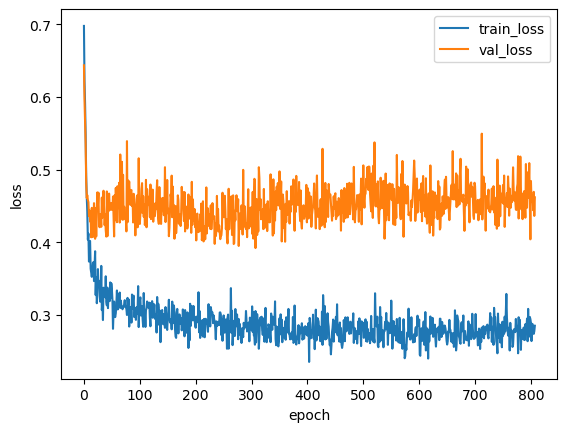

In [17]:
_ = log.plot()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.savefig(f'{SAVE_PATH}_training_curves.pdf')
log.to_pandas().to_csv(f'{SAVE_PATH}_training_curves.csv')

We can get the partial log-likelihood

In [18]:
model.partial_log_likelihood(*val).mean()

-6.3838396

## Prediction

For evaluation we first need to obtain survival estimates for the test set.
This can be done with `model.predict_surv` which returns an array of survival estimates, or with `model.predict_surv_df` which returns the survival estimates as a dataframe.

However, as `CoxCC` is semi-parametric, we first need to get the non-parametric baseline hazard estimates with `compute_baseline_hazards`. 

Note that for large datasets the `sample` argument can be used to estimate the baseline hazard on a subset.

In [19]:
_ = model.compute_baseline_hazards()

In [20]:
x_test.shape

(12500, 33)

In [21]:
x_test

array([[ 0.2       ,  0.93286633,  2.059838  , ...,  0.1140476 ,
         0.5277285 ,  1.        ],
       [ 0.4       ,  0.93286633,  2.059838  , ...,  0.1140476 ,
         0.5277285 ,  1.        ],
       [ 0.6       ,  0.93286633,  2.059838  , ...,  0.1140476 ,
         0.5277285 ,  1.        ],
       ...,
       [ 0.6       , -1.8828468 , -0.59105647, ...,  0.82853913,
        -1.0770508 ,  0.        ],
       [ 0.8       , -1.8828468 , -0.59105647, ...,  0.82853913,
        -1.0770508 ,  0.        ],
       [ 1.        , -1.8828468 , -0.59105647, ...,  0.82853913,
        -1.0770508 ,  0.        ]], dtype=float32)

In [22]:
surv = model.predict_surv_df(x_test)

In [23]:
surv

,0,1,2,3,4,5,6,7,8,9,...,12490,12491,12492,12493,12494,12495,12496,12497,12498,12499
duration,,,,,,,,,,,,,,,,,,,,,
1.0,0.459466,0.882944,0.993089,0.999662,0.999984,0.586009,0.951487,0.997970,0.999912,0.999996,...,0.726827,0.981204,0.998981,0.999945,0.999997,0.487746,0.880481,0.993766,0.999693,0.999985
2.0,0.258742,0.568059,0.946562,0.997173,0.999858,0.434407,0.790493,0.985103,0.999313,0.999969,...,0.596716,0.885674,0.993107,0.999629,0.999980,0.326526,0.658819,0.958917,0.997941,0.999899
3.0,0.164638,0.396503,0.745681,0.973946,0.998588,0.345405,0.704356,0.930563,0.994083,0.999717,...,0.521876,0.826132,0.957857,0.997042,0.999841,0.237804,0.525651,0.857045,0.983918,0.999127
4.0,0.120545,0.310521,0.643753,0.896746,0.987779,0.305002,0.659850,0.899234,0.977548,0.997538,...,0.481745,0.792508,0.937410,0.985932,0.998841,0.190811,0.465117,0.802179,0.950367,0.993005
5.0,0.085765,0.247802,0.559761,0.829001,0.945132,0.273394,0.623039,0.870248,0.959351,0.987918,...,0.450250,0.763039,0.918822,0.975731,0.993461,0.158100,0.419575,0.753983,0.917084,0.974202
6.0,0.051101,0.177960,0.453099,0.736159,0.884118,0.237761,0.570093,0.824773,0.929201,0.971015,...,0.411692,0.725699,0.893345,0.960871,0.985575,0.123078,0.360960,0.686959,0.865756,0.944250
7.0,0.028803,0.123346,0.358433,0.642962,0.819467,0.205235,0.518751,0.776319,0.893802,0.948756,...,0.376466,0.690216,0.868595,0.945860,0.976916,0.094321,0.304349,0.618151,0.811031,0.908596
8.0,0.019119,0.094953,0.303304,0.582151,0.775040,0.185396,0.486000,0.744510,0.870132,0.932559,...,0.355211,0.668098,0.852884,0.936234,0.971331,0.077970,0.268383,0.571879,0.772916,0.881937
9.0,0.011527,0.068743,0.246788,0.513019,0.721978,0.164142,0.449481,0.708119,0.842603,0.913523,...,0.332708,0.644037,0.835531,0.925509,0.965080,0.061575,0.228540,0.517756,0.726806,0.849005


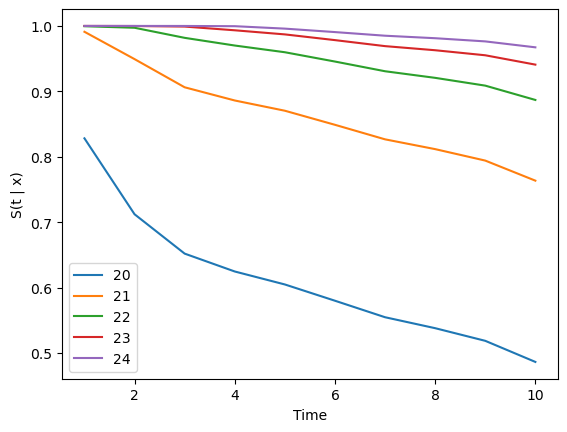

In [24]:
n = 5
surv.iloc[:, 5*(n-1):5*n].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel('Time')

In [25]:
model.save_net(SAVE_PATH)